# CSTR Control via Stochastic Policy Search

A neural network policy is trained to regulate a CSTR using **Stochastic Policy Search** (SPS) —
an evolutionary approach that requires no gradients.

Based on [Chapter 7 of *Machine Learning in Chemical Engineering*](https://edgarsmdn.github.io/MLCE_book/07_RL_Control.html) (Flores-Tlacuahuac et al., 2023).

## 1. Imports

In [1]:
from copy import deepcopy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.integrate import solve_ivp
from pylab import *


## 2. CSTR Model

Simple CSTR with exothermic reaction A → B.
States: $c_A$ (mol/m³), $T$ (K). Control input: $T_c$ (cooling jacket temperature, K).

$$\dot{c}_A = \frac{q}{V}(c_{A,f} - c_A) - k_0 e^{-E/RT} c_A$$

$$\dot{T} = \frac{q}{V}(T_f - T) + \frac{\Delta H}{\rho C_p} k_0 e^{-E/RT} c_A + \frac{UA}{\rho C_p V}(T_c - T)$$

In [2]:
def cstr(t, x, Tc):
    Ca, T = x
    # Parameters
    q, V    = 100, 100         # flowrate (m3/s), volume (m3)
    Tf, Caf = 350, 1.0         # feed temperature (K), feed concentration (mol/m3)
    rho, Cp = 1000, 0.239      # density (kg/m3), heat capacity (J/kg-K)
    mdelH   = 5e4              # heat of reaction (J/mol)
    EoverR  = 8750             # activation energy / R (K)
    k0      = 7.2e10           # pre-exponential factor (1/s)
    UA      = 5e4              # heat transfer coefficient * area (W/K)
    # Equations
    rA    = k0 * np.exp(-EoverR / T) * Ca
    dCadt = q/V * (Caf - Ca) - rA
    dTdt  = q/V * (Tf - T) + mdelH/(rho*Cp) * rA + UA/(V*rho*Cp) * (Tc - T)
    return [dCadt, dTdt]


## 3. Problem Setup

Simulate 25 minutes with a setpoint change at the midpoint.
The policy receives states and setpoint errors as inputs and outputs $T_c$.

In [3]:
# Time grid
t  = np.linspace(0, 25, 101)   # 101 points over 25 min

# Initial conditions
x0 = np.array([0.8773, 324.5])

# Setpoints (step change at midpoint)
n1 = len(t) // 2
Ca_sp = np.array([0.8]*n1 + [0.9]*(len(t)-n1))
T_sp  = np.array([330.]*n1 + [320.]*(len(t)-n1))

# Control bounds
Tc_lb, Tc_ub = 295, 305

# Input/output scaling
# Inputs: [Ca, T, e_Ca, e_T]  normalised by mean and range
x_mean  = np.array([0.8,  315.,  0.,  0.])
x_range = np.array([0.1,   10.,  0.1, 20.])
u_range, u_bias = 10/6, 295.0   # output in (0,6) -> Tc

# Noise level
noise = 0.1


## 4. Policy Network

A small network mapping $(c_A, T, e_{c_A}, e_T)$ to $T_c$.
ReLU6 output maps the network output to $(0, 6)$, then scaled to the $T_c$ operating range.

In [4]:
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 2),
            nn.LeakyReLU(0.1),
            nn.Linear(2, 1),
        )
    def forward(self, x):
        return F.relu6(self.net(x.float()))

def get_action(policy, ca, T, ca_sp, T_sp):
    """Normalise inputs and return Tc."""
    xk = np.array([ca, T, ca_sp - ca, T_sp - T])
    xk_norm = (xk - x_mean) / x_range
    with torch.no_grad():
        u = policy(torch.tensor(xk_norm)).item()
    Tc = u * u_range + u_bias
    return float(np.clip(Tc, Tc_lb, Tc_ub))


## 5. Episode Rollout

Simulate one episode (25 min) and return the total cost:

$$G = \sum_t \left(\frac{|e_{c_A,t}|}{0.2} + \frac{|e_{T,t}|}{15} + \frac{|T_{c,t} - T_{c,\text{lb}}|}{100} + \frac{|\Delta T_{c,t}|}{100}\right)$$

In [5]:
def rollout(policy, collect=False):
    x = x0.copy()
    Tc_hist, Ca_hist, T_hist = [], [x[0]], [x[1]]
    cost = 0.0
    rng = np.random.default_rng()

    for i in range(len(t) - 1):
        Tc  = get_action(policy, x[0], x[1], Ca_sp[i], T_sp[i])
        sol = solve_ivp(cstr, [t[i], t[i+1]], x, args=(Tc,))
        s   = rng.uniform(-1, 1, 2)
        x   = sol.y[:, -1] + noise * s * np.array([0.1, 5.0])

        e_ca  = abs(Ca_sp[i] - x[0])
        e_T   = abs(T_sp[i]  - x[1])
        u_mag = abs(Tc - Tc_lb) / 100
        u_cha = abs(Tc - Tc_hist[-1]) / 100 if Tc_hist else 0.0

        cost += e_ca/0.2 + e_T/15 + u_mag + u_cha
        Tc_hist.append(Tc)
        Ca_hist.append(x[0])
        T_hist.append(x[1])

    if collect:
        return cost, np.array(Ca_hist), np.array(T_hist), np.array(Tc_hist)
    return cost


## 6. Stochastic Policy Search

At each iteration:
1. Sample $K$ random perturbations of the current best weights: $\theta^{(k)} = \theta^* + \epsilon^{(k)},\; \epsilon^{(k)} \sim \mathcal{N}(0, \sigma^2 I)$
2. Roll out each policy; compute cost $G^{(k)}$
3. Keep the best-performing weights as the new $\theta^*$

No gradients are computed — the search is purely based on episode returns.

In [6]:
def sps(n_iter=200, K=10, sigma=0.3, seed=0):
    torch.manual_seed(seed)
    policy = PolicyNet()
    best_params = deepcopy(policy.state_dict())
    best_cost   = rollout(policy)
    cost_history = [best_cost]

    for it in range(n_iter):
        for _ in range(K):
            # Perturb weights
            candidate = {k: v + sigma * torch.randn_like(v)
                         for k, v in best_params.items()}
            policy.load_state_dict(candidate)
            cost = rollout(policy)
            if cost < best_cost:
                best_cost   = cost
                best_params = deepcopy(candidate)

        # Reduce perturbation radius over time
        sigma = max(sigma * 0.995, 0.01)
        cost_history.append(best_cost)
        if (it+1) % 50 == 0:
            print(f'iter {it+1:4d}  best cost = {best_cost:.3f}  sigma = {sigma:.4f}')

    policy.load_state_dict(best_params)
    return policy, cost_history

policy, cost_history = sps(n_iter=200, K=10, sigma=0.3)


C:\Users\Mikey\AppData\Local\Temp\ipykernel_21300\258297955.py:12: RuntimeWarning: overflow encountered in exp
  rA    = k0 * np.exp(-EoverR / T) * Ca
c:\Users\Mikey\Desktop\CHE891_Classwork\py312_env\Lib\site-packages\scipy\integrate\_ivp\rk.py:66: RuntimeWarning: invalid value encountered in dot
  y_new = y + h * np.dot(K[:-1].T, B)
c:\Users\Mikey\Desktop\CHE891_Classwork\py312_env\Lib\site-packages\scipy\integrate\_ivp\rk.py:106: RuntimeWarning: invalid value encountered in dot
  return np.dot(K.T, self.E) * h


iter   50  best cost = 17.103  sigma = 0.2335
iter  100  best cost = 16.404  sigma = 0.1817
iter  150  best cost = 16.404  sigma = 0.1414
iter  200  best cost = 16.052  sigma = 0.1101


## 7. Training Convergence

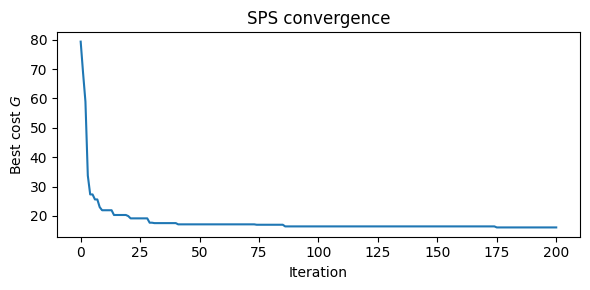

In [7]:
figure(figsize=(6, 3))
plot(cost_history, 'C0')
xlabel('Iteration');  ylabel('Best cost $G$')
title('SPS convergence')
tight_layout();  show()


## 8. Final Policy Performance

Roll out the trained policy once (no noise) to visualise setpoint tracking.

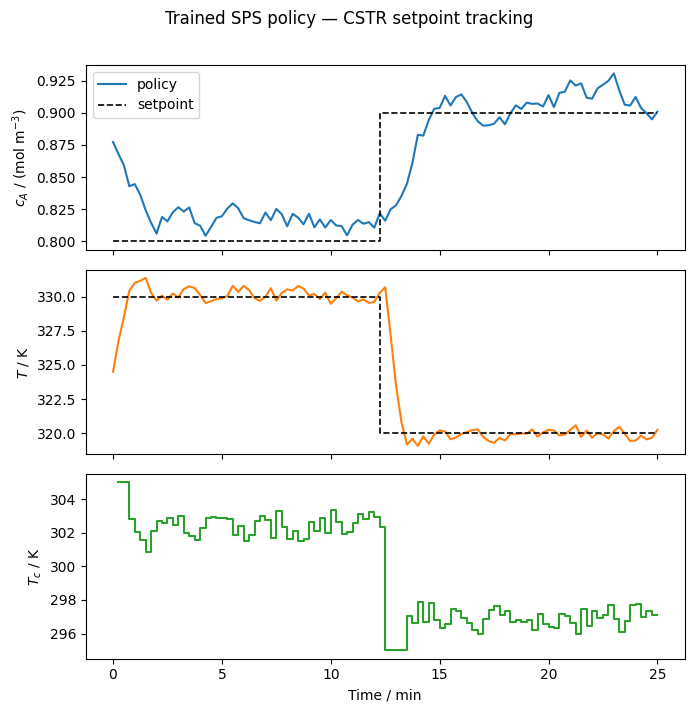

In [8]:
_, Ca_out, T_out, Tc_out = rollout(policy, collect=True)

fig, axes = subplots(3, 1, figsize=(7, 7), sharex=True)

axes[0].plot(t, Ca_out, 'C0');  axes[0].step(t, Ca_sp, 'k--', lw=1.2)
axes[0].set_ylabel(r'$c_A$ / (mol m$^{-3}$)');  axes[0].legend(['policy', 'setpoint'])

axes[1].plot(t, T_out, 'C1');  axes[1].step(t, T_sp, 'k--', lw=1.2)
axes[1].set_ylabel('$T$ / K')

axes[2].step(t[1:], Tc_out, 'C2')
axes[2].set_ylabel('$T_c$ / K');  axes[2].set_xlabel('Time / min')

suptitle('Trained SPS policy — CSTR setpoint tracking', y=1.01)
tight_layout();  show()
